In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import glob

path = "/content/drive/MyDrive/공모전/T14/*.csv"
files = glob.glob(path)

print("전체 파일:", len(files))

for f in files:
    print(f)

전체 파일: 36
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202412_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202407_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202408_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202409_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202410_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202411_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202406_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202405_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202404_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202401_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202403_성남시.csv
/content/drive/MyDrive/공모전/T14/T14_GG_TRANS_SEXAGE_SGG_OD_202402_성남ᄉ

In [29]:
import pandas as pd

df_list = []

for file in files:
    # 파일명에서 2023 포함된 것만
    if "_2023" in file:
        temp = pd.read_csv(file)
        month = file.split("_")[5]
        temp["month"] = month

        df_list.append(temp)

print("2023 파일 개수:", len(df_list))

df_2023 = pd.concat(df_list, ignore_index=True)

2023 파일 개수: 12


In [30]:
df_2023["month"].value_counts().sort_index()

,count
month,
OD,2838736


In [31]:
df_2023.head()

,ETL_YM,DOW,O_CTY_CD,O_MEGA_NM,O_CTY_NM,O_CENTER_X,O_CENTER_Y,D_CTY_CD,D_MEGA_NM,D_CTY_NM,D_CENTER_X,D_CENTER_Y,TRANS_GB,SEX_CD,AGE_GRP,CNT,month
0,202302,토,11170,서울특별시,용산구,954034,1948136,41133,경기도,성남시 중원구,970268,1937199,1,M,4,15.72,OD
1,202302,목,11740,서울특별시,강동구,968818,1950185,41131,경기도,성남시 수정구,964981,1937423,3,M,5,3.93,OD
2,202302,월,41131,경기도,성남시 수정구,964981,1937423,41610,경기도,광주시,982398,1933792,3,W,5,11.10,OD
3,202302,일,44810,충청남도,예산군,936046,1852755,41135,경기도,성남시 분당구,965120,1931210,5,W,3,5.73,OD
4,202302,수,44200,충청남도,아산시,953586,1867845,41131,경기도,성남시 수정구,964981,1937423,0,W,4,4.88,OD


In [32]:
df_2023["D_CTY_NM"].isna().sum()

np.int64(7967)

In [33]:
df_seongnam["TRANS_GB"].unique()

array([1, 3, 5, 0, 2, 7, 6, 4])

In [34]:
df_commute_in = df_2023[
    (df_2023["D_CTY_NM"].str.contains("성남", na=False)) &
    (df_2023["TRANS_GB"] == 1)]

In [35]:
df_commute_out = df_2023[
    (df_2023["O_CTY_NM"].str.contains("성남", na=False)) &
    (df_2023["TRANS_GB"] == 1)]

In [36]:
inflow = df_commute_in["CNT"].sum()
outflow = df_commute_out["CNT"].sum()

print("출근 유입:", inflow)
print("퇴근 유출:", outflow)

출근 유입: 135407092.93999997
퇴근 유출: 136975093.60999998


In [37]:
df_commute_out.groupby("D_CTY_NM")["CNT"].sum().sort_values(ascending=False).head(10)

,CNT
D_CTY_NM,
성남시 분당구,57705704.53
성남시 중원구,26025217.66
성남시 수정구,21329363.40
광주시,8222415.65
용인시 수지구,5722432.69
송파구,4133390.55
용인시 기흥구,2566268.76
강남구,2341562.12
서초구,1535552.82


In [38]:
#목적이 출퇴근인 사람 = 직장인
df_commute_all = pd.concat([df_commute_in, df_commute_out])

In [39]:
result = df_commute_all.groupby(["AGE_GRP", "SEX_CD"])["CNT"].sum().reset_index()

In [40]:
total = result["CNT"].sum()
result["ratio"] = result["CNT"] / total

In [41]:
result

,AGE_GRP,SEX_CD,CNT,ratio
0,1,M,1039951.47,0.003818
1,1,W,1308739.51,0.004805
2,2,M,9944319.71,0.036509
3,2,W,10091838.72,0.037050
4,3,M,18841053.74,0.069171
5,3,W,18600060.79,0.068287
6,4,M,22796501.41,0.083693
7,4,W,21916303.56,0.080462
8,5,M,24125002.84,0.088570
9,5,W,27021732.17,0.099205


In [43]:
age_only = df_commute_all.groupby("AGE_GRP")["CNT"].sum().reset_index()
print(age_only)

    AGE_GRP          CNT
0         1   2348690.98
1         2  20036158.43
2         3  37441114.53
3         4  44712804.97
4         5  51146735.01
5         6  56197199.14
6         7  42193668.65
7         8  14728316.02
8         9   3417513.31
9        10    158767.70
10       11      1217.81


In [44]:
sex_only = df_commute_all.groupby("SEX_CD")["CNT"].sum().reset_index()
print(sex_only)

  SEX_CD           CNT
0      M  1.311512e+08
1      W  1.412310e+08


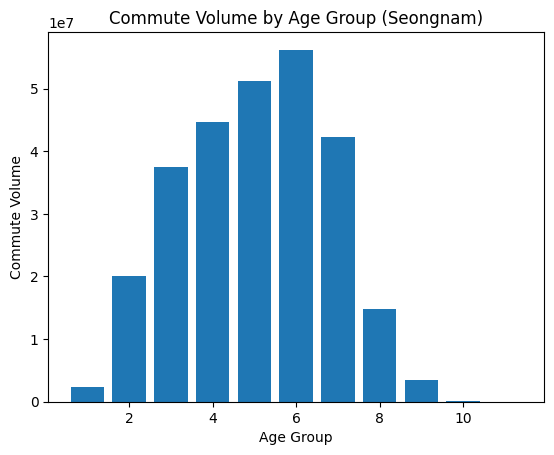

In [45]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(age_only["AGE_GRP"], age_only["CNT"])

plt.xlabel("Age Group")
plt.ylabel("Commute Volume") # 이동량
plt.title("Commute Volume by Age Group (Seongnam)")

plt.show()

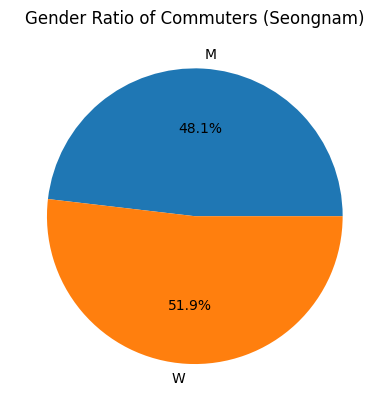

In [47]:
plt.figure()

plt.pie(sex_only["CNT"], labels=sex_only["SEX_CD"], autopct='%1.1f%%')

plt.title("Gender Ratio of Commuters (Seongnam)")

plt.show()

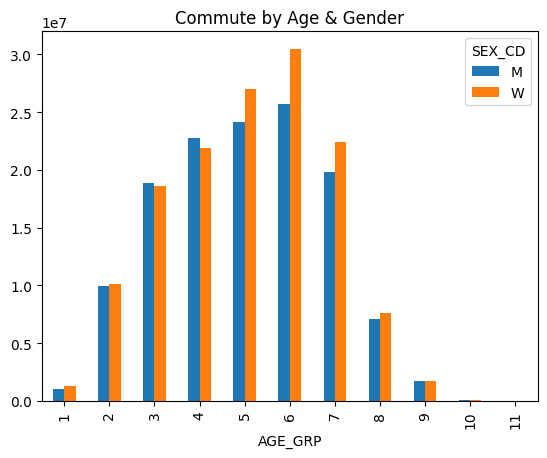

In [48]:
pivot = df_commute_all.pivot_table(
    index="AGE_GRP",
    columns="SEX_CD",
    values="CNT",
    aggfunc="sum"
)

pivot.plot(kind="bar")

plt.title("Commute by Age & Gender")
plt.show()